In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Import data and split for test-train

In [56]:
mnistData = pd.read_csv("MnistDataset.csv")

In [57]:
mnistData.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
mnistData.shape

(42000, 785)

In [59]:
data = np.array(mnistData)

X = data[:, 1:]  # Take all rows (label) , columns 1 → end (pixels)
y = data[:, 0 ]  # Take all rows (label) , 1st column

# Normalizing input ( Converting pixel values from 0-255 into 0-1 ) 
X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2)
X_train = X_train.T
X_test = X_test.T

### Forward Propagation

In [60]:
def relu(x):
    return max(x, 0)

In [61]:
def init_params ():
    W1 = np.random.rand(10, 784)
    b1 = np.random.rand(10, 1)
    W2 = np.random.rand(10, 10)
    b2 = np.random.rand(10, 1)

    return W1, b1, W2, b2

In [62]:
def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

In [63]:
def forward_prop ( W1, b1 , W2, b2, X ):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    
    return Z1, A1, Z2, A2

In [64]:
def ReLU_deriv(Z):
    return Z > 0
    
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [65]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [66]:
W1, b1, W2, b2 = gradient_descent(X_train, y_train, 0.01, 500)

Iteration:  0
[6 6 6 ... 6 6 6] [4 4 6 ... 9 4 9]
0.09708333333333333
Iteration:  10
[0 1 0 ... 0 0 0] [4 4 6 ... 9 4 9]
0.1481547619047619
Iteration:  20
[7 7 7 ... 7 7 7] [4 4 6 ... 9 4 9]
0.10553571428571429
Iteration:  30
[1 1 1 ... 1 1 1] [4 4 6 ... 9 4 9]
0.11098214285714286
Iteration:  40
[0 3 0 ... 3 0 3] [4 4 6 ... 9 4 9]
0.11976190476190476
Iteration:  50
[4 4 4 ... 4 4 4] [4 4 6 ... 9 4 9]
0.09720238095238096
Iteration:  60
[9 9 9 ... 9 9 9] [4 4 6 ... 9 4 9]
0.1636607142857143
Iteration:  70
[9 9 9 ... 9 9 9] [4 4 6 ... 9 4 9]
0.09991071428571428
Iteration:  80
[3 3 3 ... 3 3 3] [4 4 6 ... 9 4 9]
0.104375
Iteration:  90
[7 7 6 ... 7 6 7] [4 4 6 ... 9 4 9]
0.14889880952380952
Iteration:  100
[3 3 3 ... 3 3 3] [4 4 6 ... 9 4 9]
0.104375
Iteration:  110
[5 5 5 ... 5 5 5] [4 4 6 ... 9 4 9]
0.09092261904761904
Iteration:  120
[5 5 5 ... 5 5 5] [4 4 6 ... 9 4 9]
0.09761904761904762
Iteration:  130
[0 0 0 ... 0 0 0] [4 4 6 ... 9 4 9]
0.09860119047619048
Iteration:  140
[3 3 3 ... 

In [69]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

### Examples

Prediction:  [9]
Label:  4


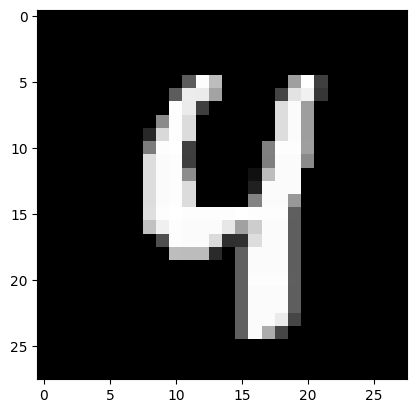

Prediction:  [5]
Label:  4


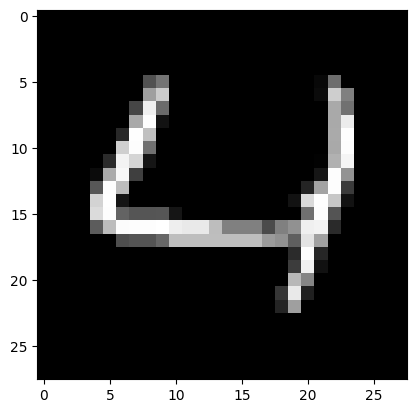

Prediction:  [6]
Label:  6


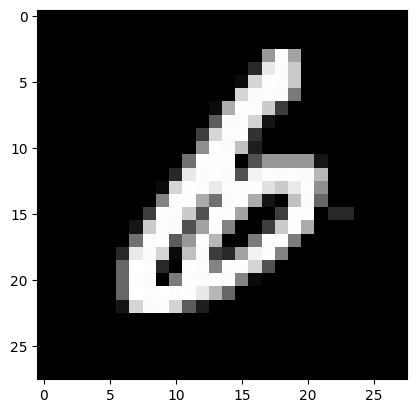

Prediction:  [6]
Label:  6


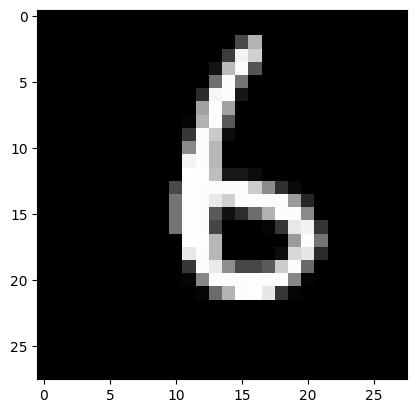

In [70]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)